In [3]:
import os
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Useful for tracking progress in Jupyter

# --- Helper Functions ---
def parse_info(info_str):
    info_dict = {}
    if not info_str or info_str == ".":
        return info_dict
    for item in info_str.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            info_dict[k] = v
        else:
            info_dict[item] = "Yes"
    return info_dict

def is_gzipped(file_path):
    try:
        with open(file_path, 'rb') as f:
            return f.read(2) == b'\x1f\x8b'
    except Exception:
        return False

# --- Main Loading Logic ---
def load_data_from_manifest(csv_path):
    manifest = pd.read_csv(csv_path)
    records = []
    
    print(f"Processing {len(manifest)} samples from manifest...")
    
    for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
        vcf_path = row['vcf_path']
        sample_id = row['sample_id']
        sample_type = row['sample_type']
        
        if not os.path.exists(vcf_path):
            print(f"[WARN] File not found: {vcf_path}")
            continue
            
        openf = gzip.open if is_gzipped(vcf_path) else open
        
        try:
            with openf(vcf_path, "rt") as f:
                for line in f:
                    if line.startswith("#"):
                        continue
                    fields = line.strip().split("\t")
                    if len(fields) < 8: continue
                        
                    info = parse_info(fields[7])
                    
                    try:
                        indel_len = int(float(info.get("INDEL_LENGTH", 0)))
                        hp_len = int(float(info.get("HOMOPOLYMER_LEN", 0)))
                        rp_med = float(info.get("RP_MED_SSCS", 0.0))
                        sb_str = info.get("STRAND_BIAS_SSCS")
                        strand_bias = float(sb_str) if sb_str is not None else np.nan
                        
                        records.append({
                            "sample_id": sample_id,
                            "sample_type": sample_type,
                            "Type": "Insertion" if indel_len > 0 else "Deletion" if indel_len < 0 else "Other",
                            "Length": abs(indel_len),
                            "Homopolymer_Length": hp_len,
                            "Read_Position": rp_med,
                            "Strand_Bias": strand_bias
                        })
                    except (ValueError, TypeError):
                        continue
        except Exception as e:
            print(f"[ERROR] Could not parse {vcf_path}: {e}")
                
    return pd.DataFrame(records)

# Load the data (Update the path to your master CSV)
csv_manifest_path = "../../data/indels/filtered_WES_denominator_v2_indel_20_features/master_list.csv" 
df = load_data_from_manifest(csv_manifest_path)

# Filtering
df = df[df["Type"].isin(["Insertion", "Deletion"])]
print(f"\nSuccessfully loaded {len(df)} variants.")
df.head()

Processing 36 samples from manifest...


100%|██████████| 36/36 [00:00<00:00, 627.13it/s]


Successfully loaded 1359 variants.


,sample_id,sample_type,Type,Length,Homopolymer_Length,Read_Position,Strand_Bias
0,27YO_UDI5,T_cells,Deletion,1,0,0.239,1.0
1,27YO_UDI5,T_cells,Deletion,2,1,0.393,0.0
2,27YO_UDI5,T_cells,Deletion,1,0,0.504,0.5
3,27YO_UDI5,T_cells,Deletion,1,0,0.119,0.5
4,27YO_UDI5,T_cells,Deletion,6,0,0.761,0.5


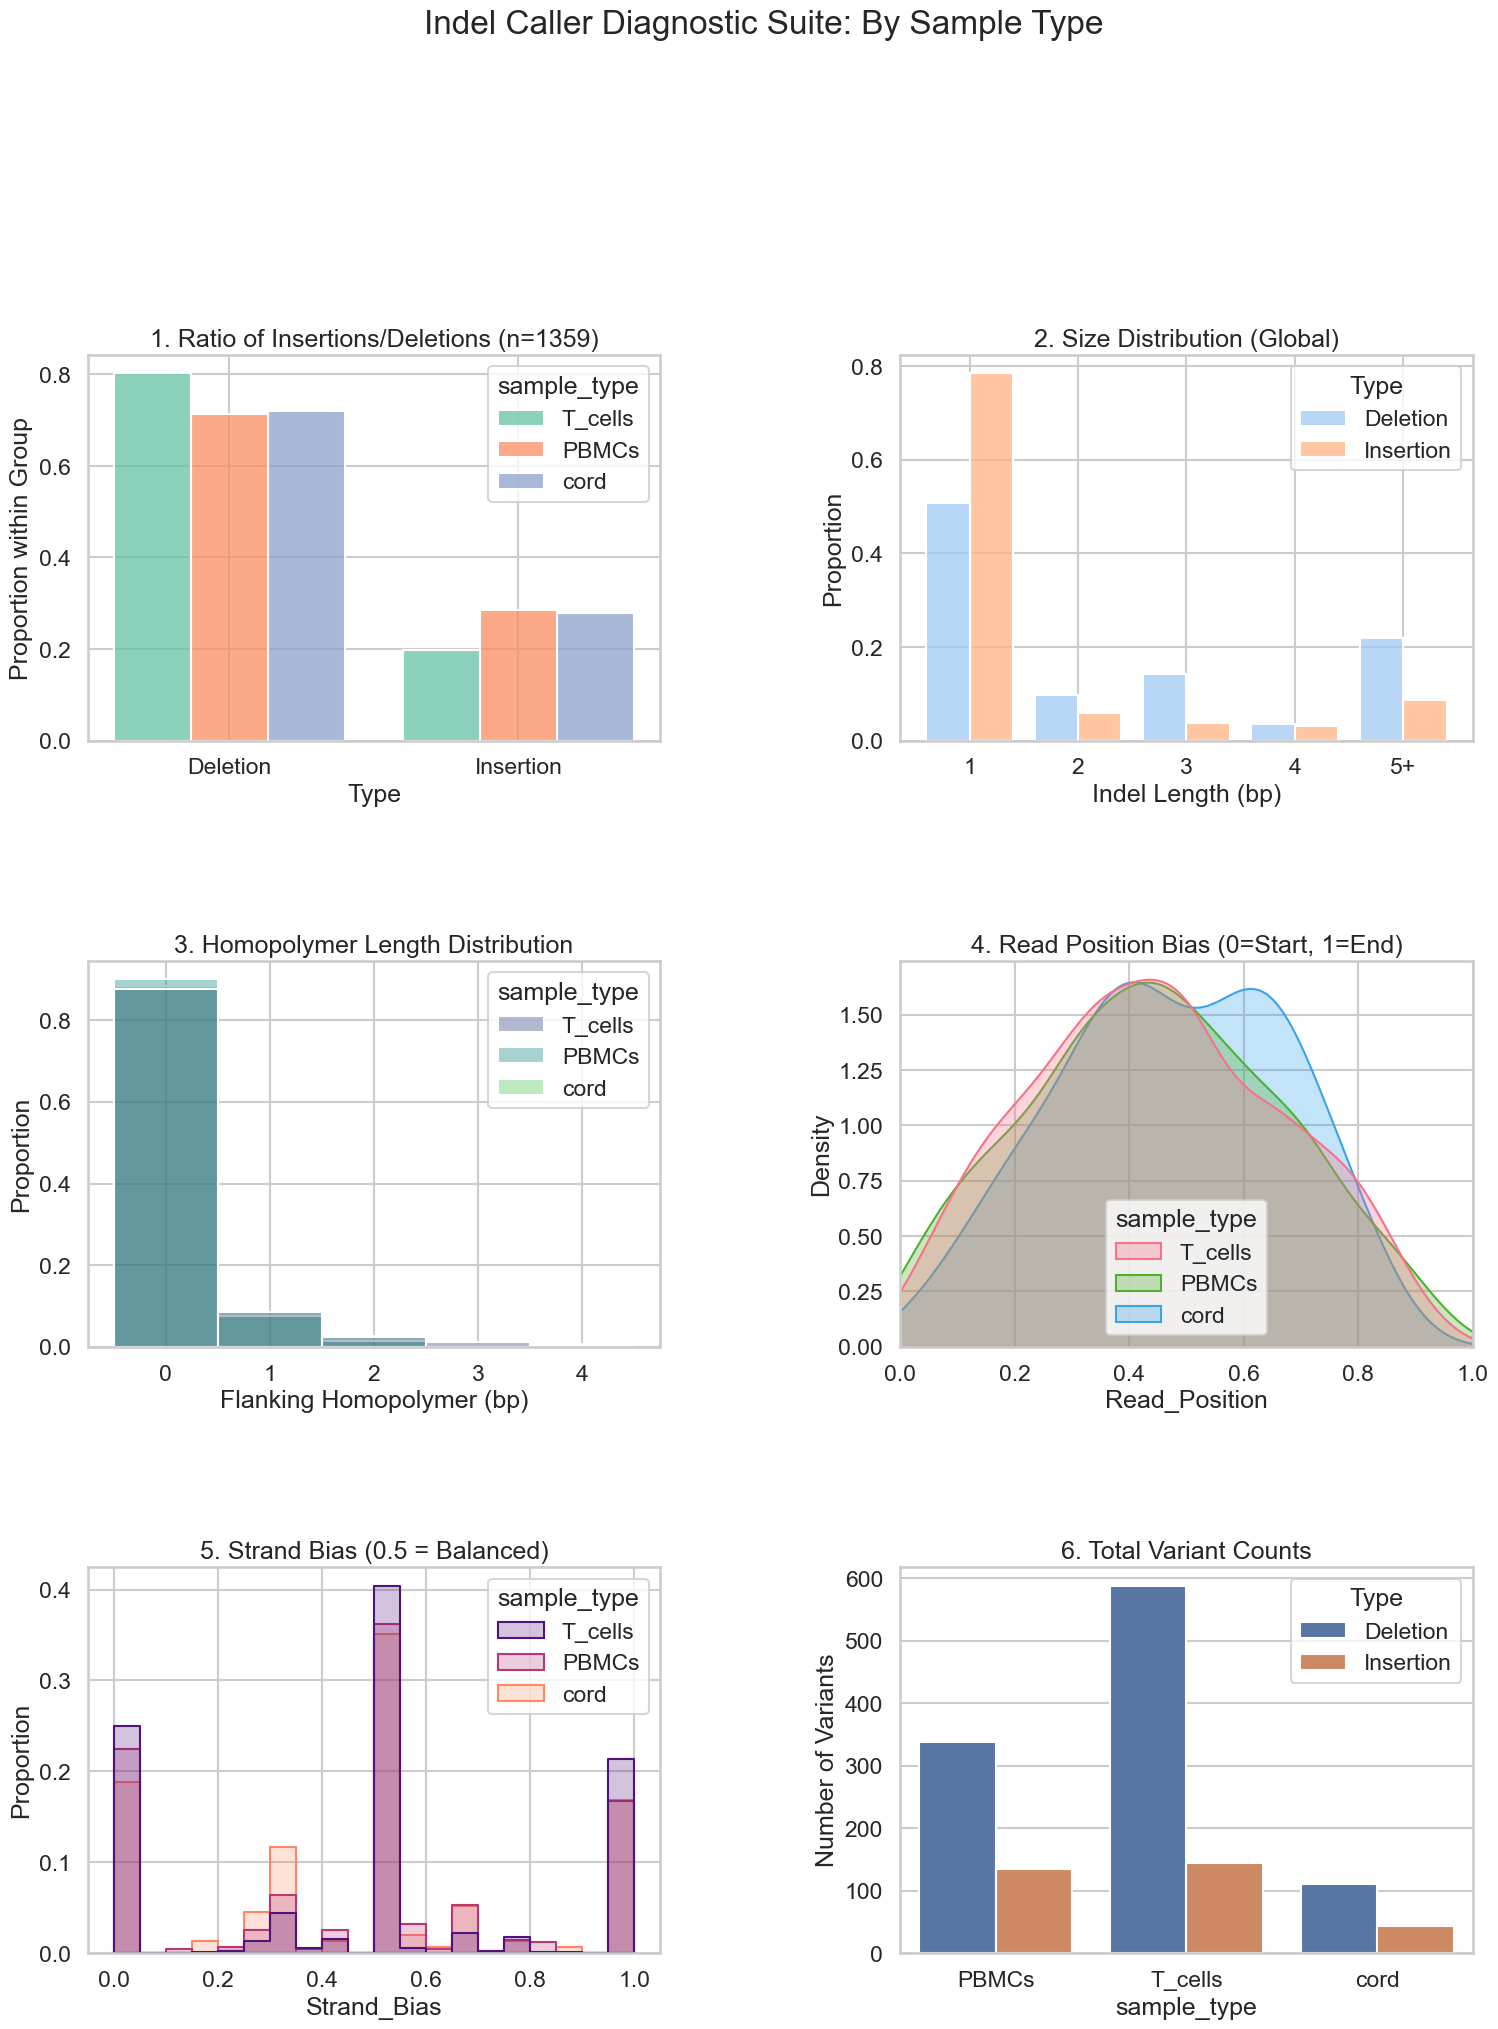

In [4]:
# Set plotting style
sns.set_theme(style="whitegrid", context="talk")

if df.empty:
    print("[ERROR] No data available to plot.")
else:
    # Use 'sample_type' for categorical grouping
    group_col = "sample_type" 
    
    fig, axes = plt.subplots(3, 2, figsize=(18, 22))
    fig.suptitle("Indel Caller Diagnostic Suite: By Sample Type", fontsize=24, y=0.98)
    fig.tight_layout(pad=7.0)

    # --- PLOT 1: Deletions vs Insertions ---
    sns.histplot(data=df, x="Type", hue=group_col, multiple="dodge", stat="proportion", 
                 common_norm=False, shrink=0.8, ax=axes[0, 0], palette="Set2")
    axes[0, 0].set_title(f"1. Ratio of Insertions/Deletions (n={len(df)})")
    axes[0, 0].set_ylabel("Proportion within Group")

    # --- PLOT 2: Indel Size Distribution ---
    df["Plot_Length"] = pd.Categorical(df["Length"].apply(lambda x: str(x) if x < 5 else "5+"), 
                                       categories=["1", "2", "3", "4", "5+"], ordered=True)
    sns.histplot(data=df, x="Plot_Length", hue="Type", multiple="dodge", stat="proportion", 
                 common_norm=False, shrink=0.8, ax=axes[0, 1], palette="pastel")
    axes[0, 1].set_title("2. Size Distribution (Global)")
    axes[0, 1].set_xlabel("Indel Length (bp)")

    # --- PLOT 3: Homopolymer Context ---
    sns.histplot(data=df, x="Homopolymer_Length", hue=group_col, multiple="layer", 
                 discrete=True, stat="proportion", common_norm=False, ax=axes[1, 0], palette="viridis", alpha=0.4)
    axes[1, 0].set_title("3. Homopolymer Length Distribution")
    axes[1, 0].set_xlabel("Flanking Homopolymer (bp)")

    # --- PLOT 4: Read Position Bias ---
    sns.kdeplot(data=df, x="Read_Position", hue=group_col, fill=True, 
                common_norm=False, ax=axes[1, 1], palette="husl", alpha=0.3)
    axes[1, 1].set_title("4. Read Position Bias (0=Start, 1=End)")
    axes[1, 1].set_xlim(0, 1.0) 

    # --- PLOT 5: Strand Bias ---
    df_sb = df.dropna(subset=['Strand_Bias'])
    if not df_sb.empty:
        sns.histplot(data=df_sb, x="Strand_Bias", hue=group_col, multiple="layer", 
                     bins=20, stat="proportion", common_norm=False, element="step", 
                     ax=axes[2, 0], palette="magma")
        axes[2, 0].set_title("5. Strand Bias (0.5 = Balanced)")
        axes[2, 0].set_xlim(-0.05, 1.05) 
    else:
        axes[2, 0].text(0.5, 0.5, "No SB Info", ha='center')

    # --- PLOT 6: Variants per Sample Type (Summary) ---
    counts = df.groupby([group_col, "Type"]).size().reset_index(name='count')
    sns.barplot(data=counts, x=group_col, y='count', hue='Type', ax=axes[2, 1])
    axes[2, 1].set_title("6. Total Variant Counts")
    axes[2, 1].set_ylabel("Number of Variants")

    plt.show()